In [2]:
from matplotlib import pyplot as plt

In [3]:
"""
Необходимо добавлять путь к библиотеки только в jupyter
"""
from os.path import dirname, abspath
path_library = dirname(abspath(".."))

try:
    from geotechnical_solutions.GeoSimModel.create_models.geology_models import *    # Путь к классу для создания геологии

except ModuleNotFoundError as ex:
    import sys
    sys.path.append(path_library)
    print("Добавление пути к библиотеки geotechnical_solutions")
    from geotechnical_solutions.GeoSimModel.create_models.geology_models import *
     
from geotechnical_solutions.GeoSimModel.create_models.foundation_models import *    # Путь к классу для создания сваи
from geotechnical_solutions.GeoSimModel.solve.building_analysis import *
from geotechnical_solutions.GeoSimModel import path_data    # Получить путь к табличным данным СП (нужно для расчетов)

Добавление пути к библиотеки geotechnical_solutions


# Тестовые варианты расчета осадки и ГСТ

## Тест 1

In [4]:
"""
Входные данные
"""
counts_ige = 3
dict_ige = {}
dict_soil = {}

for i in range(counts_ige):
    dict_ige[f"ige{i+1}"] = 0
    dict_soil[f"soil{i}"] = f"ige{i+1}"

E = [20e6, 30e6, 40e6]
gamma = [18e3, 19e3, 20e3]
z_soils = [30, 20, 10, 0]
water_soils = [[26, 24], [18, 11], False]

P = 500e3
H_found = 5
f_length = 2
f_width = 2

In [39]:
"""
Входные данные
"""
counts_ige = 7
dict_ige = {}
dict_soil = {}

for i in range(counts_ige):
    dict_ige[f"ige{i+1}"] = 0
    dict_soil[f"soil{i}"] = f"ige{i+1}"

E = [11e6, 7e6, 6.1e6, 4.5e6, 6.1e6, 7e6, 11.2e6]
gamma = [17640,
        18522,
        19012,
        19012,
        19012,
        18522,
        19306
        ]
z_soils = [126.6, 
           125.22, 
           124.12,
           117.62, 
           112.85, 
           104.39, 
           98.3,
           40
          ]

water_soils = [False,
               False,
               [123.79, 117.62],
               True,
               True,
               True,
               True
              ]
               

P = 160000
H_found = 0
f_length = 1.4
f_width = 14.3

In [40]:
"""
Создание материалов
"""
for i, ige in enumerate(dict_ige):
    dict_ige[ige] = CreateMaterial()
    dict_ige[ige].change = ("E", E[i])
    dict_ige[ige].change = ("gamma", gamma[i])

"""
Создание скважины
"""
Borehole_1 = CreateBorehole(0, 0)

"""
Создание слоев в скважине
"""
for i, soil in enumerate(dict_soil):
    Borehole_1.createSoil(bot=z_soils[i + 1],
                          water=water_soils[i],
                          material=dict_ige[dict_soil[soil]]
                          )
Borehole_1.change[0][0].change["Top"] = z_soils[0]

"""
Создание нагрузки и плиты
"""
load_1 = CreateLoad(Type="P", load=P)
plate_1 = CreatePlate(FL=z_soils[0]-H_found, length=f_length, width=f_width)
plate_1.change["Load"] = load_1

In [41]:
"""
Вычисление напряжений
"""
Mps = LayerSumMethod(Borehole_1,
                     plate_1,
                     load_1,
                     type_found="ленточный",
                     path_alpha = path_data+r"alpha_table.txt"
                     )
Mps.calculation()

In [42]:
print(f"осадка {Mps.Output()[0]}")
print(f"ГСТ: {(z_soils[0] - H_found) - Mps.comparison()[0]}")
print(f"Отметка и номер слоя: {Mps.comparison()}")

осадка 0.32360707735670147
ГСТ: 13.75
Отметка и номер слоя: (112.85, 3)


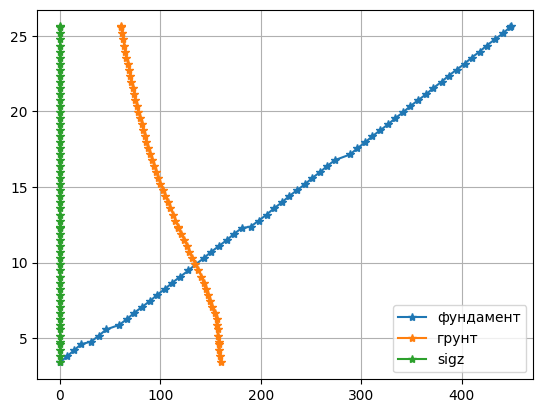

In [43]:
result_dict = Mps.Output()[1]
depth = []
sigx = []
sigy = []
sigz = []

for key, item in result_dict.items():
    _, x, y, z = item
    sigx.append(int(x/1000))
    sigy.append(int(y/1000))
    sigz.append(int(z/1000))
    depth.append(130-float(key))


plt.plot(sigx, depth, "-*", label="фундамент")
plt.plot(sigy, depth, "-*", label="грунт")
plt.plot(sigz, depth, "-*", label="sigz")
plt.grid(True)
plt.legend()
plt.show()

In [37]:
import numpy as np
np.array(sigx)
np.where(np.array(sigx) < np.array(sigy))

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16],
       dtype=int64),)

In [38]:
sigx[30], sigy[30]

(236, 103)

In [18]:
np.array(sigx)

array([160, 159, 158, 158, 158, 157, 157, 156, 156, 154, 151, 149, 147,
       145, 143, 141, 138, 135, 132, 129, 127, 124, 121, 118, 118, 115,
       113, 110, 108, 105, 103, 100,  98,  96,  94,  92,  90,  88,  86,
        85,  83,  82,  80,  78,  77,  75,  74,  73,  71,  70,  69,  68,
        66,  65,  64,  63,  62,  61,  61])